# SHL Hiring Assessment 2026: Grammar Scoring Engine for Spoken English

**Task.** Predict a 0–5 grammar score (MOS Likert, rubric below) for each 45–60 s spoken-English audio clip.
**Data.** 769 labelled training clips, 216 test clips. **Leaderboard metric.** RMSE and Pearson correlation.

**Result.** Best public leaderboard score **0.3224**: four models, including an audio language model (Voxtral), with a
measured test-set bias removed and the spread of the full-length test clips restored (§9).
Training-data RMSE and Pearson are reported in §6 (compulsory).

| Score | Rubric (abridged) |
|---|---|
| 1 | Struggles with sentence structure; limited control of simple structures |
| 2 | Simple structures with consistent basic errors; incomplete sentences |
| 3 | Decent grasp of either grammar or sentence structure, with errors in the other |
| 4 | Strong control; occasional minor errors that don't impede understanding |
| 5 | High accuracy, complex structures handled well, self-corrections |

### Contents
1. Approach at a glance
2. Setup
3. Data exploration
4. Pipeline (raw audio → features → models → blend)
5. Validation design: why plain CV was misleading
6. Evaluation on the training data (RMSE, Pearson)
7. Visual diagnostics
8. Leaderboard progression and what we tested
9. The leaderboard metric and the test-set bias
10. Submission

## 1. Approach at a glance

Each clip is described from two angles and the views are combined at the end:

* **What was said (text).** Whisper-large-v3-turbo transcribes the audio. A *verbatim* prompt full of fillers
  and grammar mistakes stops Whisper from silently correcting the speaker (it otherwise turns "he don't"
  into "he doesn't", erasing exactly the signal we need). From the transcript: length-robust text statistics
  plus ASR confidence (LightGBM), and DeBERTa-v3-large sentence embeddings (Ridge).
* **How it was said (audio).** Frozen speech encoders, WavLM-base-plus, WavLM-large and the Whisper encoder,
  are pooled over 20 s windows (mean and std of middle layers) and fed to Ridge and SVR regressors. Audio turned
  out to be the strongest single view: fluency, rhythm and pronunciation track the grammar score closely.
* **Blend.** A non-negative linear blend of all models' out-of-fold predictions, plus a **score-0 gate**:
  WavLM separates the 37 score-0 training clips perfectly, so clips it scores below 0.5 are set to 0.

Two findings shaped the final model more than any architecture choice (details in §5):
1. **Speaker leakage.** Training speakers repeat. Random CV folds let a model "recognise the voice", so all
   models are validated with **speaker-grouped folds**.
2. **Clip-length shift.** 70% of test clips are ≤ 55 s, against 25% of training clips, and audio models
   systematically shift with length. Every model is therefore trained and validated on **test-length crops** of
   the training clips as well, with **transcripts of those crops** for the text models.

## 2. Setup

The pipeline lives in plain, commented Python scripts (`src/01_*.py` … `src/10_*.py`); this notebook runs them
in order and then analyses the results. On Kaggle (2× T4) it runs the full pipeline from raw audio, about 3 hours.
Locally it reuses the cached outputs in `artifacts/`.

In [1]:
import glob, importlib, os, subprocess, sys
from pathlib import Path

if Path("/kaggle/input").exists():   # same transformers version the pipeline was developed with
    subprocess.run(f"{sys.executable} -m pip install -q transformers==5.18.0 'mistral-common[audio]'", shell=True, check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the pipeline code: the attached Kaggle dataset 'shl-src', or ../src in the GitHub repo.
SRC = Path(os.path.dirname(glob.glob("/kaggle/input/**/01_transcribe.py", recursive=True)[0])
           if Path("/kaggle/input").exists() else Path("..") / "src").resolve()
sys.path.insert(0, str(SRC))
from common import ART, DATA, ON_KAGGLE   # data/artifact paths shared by every script

RUN_PIPELINE = ON_KAGGLE   # rebuild everything from raw audio on Kaggle; reuse cached artifacts locally
print(f"python: {sys.executable}\ncode: {SRC}\ndata: {DATA}\nartifacts: {ART}\nrun pipeline: {RUN_PIPELINE}")

# Chart style: thin marks, recessive axes, text in ink colours (blue/orange = validated categorical pair).
BLUE, ORANGE, INK, MUTED, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "font.size": 10, "figure.dpi": 110})

D:\SHLHIRINGASS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python: D:\SHLHIRINGASS\.venv\Scripts\python.exe
code: D:\SHLHIRINGASS\src
data: D:\SHLHIRINGASS\data\Dataset_Final
artifacts: D:\SHLHIRINGASS\artifacts
run pipeline: False


## 3. Data exploration

In [2]:
import soundfile as sf

train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")   # its 'label' column is a placeholder (-1)
train["duration"] = [sf.info(DATA / "train" / f).duration for f in train.filename]
test["duration"] = [sf.info(DATA / "test" / f).duration for f in test.filename]
print(f"train: {len(train)} clips, label mean {train.label.mean():.2f}, std {train.label.std():.2f}")
print(f"test : {len(test)} clips")
print("label counts:", train.label.value_counts().sort_index().to_dict())

train: 769 clips, label mean 3.31, std 1.24
test : 216 clips
label counts: {0.0: 37, 1.0: 1, 1.5: 3, 2.0: 102, 2.5: 79, 3.0: 174, 3.5: 64, 4.0: 124, 4.5: 52, 5.0: 133}


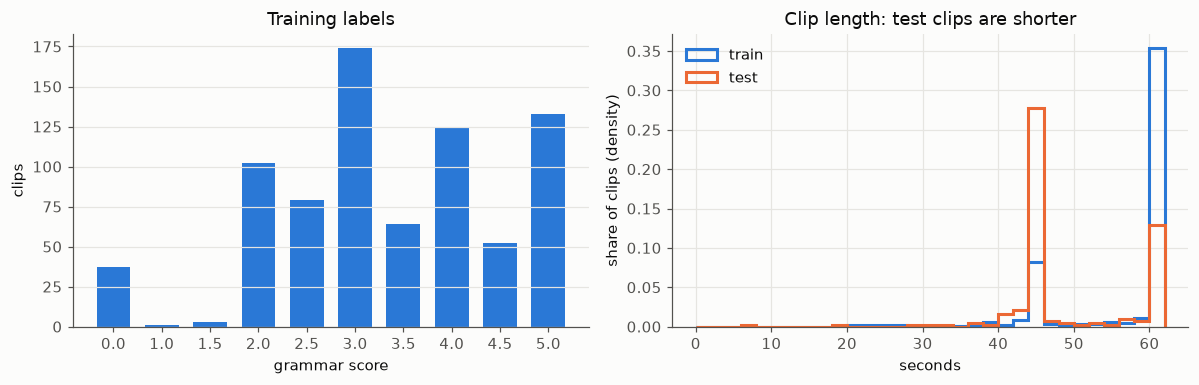

clips <= 55 s: train 26%, test 71%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

counts = train.label.value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color=BLUE, width=0.7)
axes[0].set(title="Training labels", xlabel="grammar score", ylabel="clips")
axes[0].grid(axis="x", visible=False)

bins = np.arange(0, 64, 2)
axes[1].hist(train.duration, bins=bins, density=True, histtype="step", lw=2, color=BLUE, label="train")
axes[1].hist(test.duration, bins=bins, density=True, histtype="step", lw=2, color=ORANGE, label="test")
axes[1].set(title="Clip length: test clips are shorter", xlabel="seconds", ylabel="share of clips (density)")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

share = lambda d: (d <= 55).mean()
print(f"clips <= 55 s: train {share(train.duration):.0%}, test {share(test.duration):.0%}")

**Observations.**
* Labels cluster at 2–5; 37 clips score **0**, with almost nothing between 0 and 2. The score-0 clips contain
  ordinary speech, but WavLM separates them perfectly, so the difference is acoustic (likely recording
  conditions). That is what the score-0 gate uses.
* **Test clips are shorter** (median 45 s vs 60 s), and many of them end mid-speech, so they look cut rather than
  naturally finished. In training, short clips really do score lower (speakers who run out of things to say),
  so a model can learn "less audio = lower score". §5 shows the fix.

## 4. Pipeline

| Step | Script | What it produces |
|---|---|---|
| 1 | `01_transcribe.py` | Whisper transcripts (verbatim prompt) + ASR confidence, for full clips and test-length crops |
| 2 | `02_text_features.py` | Length-robust text statistics (rates, ratios, vocabulary richness) |
| 4 | `04_text_embed.py` | Frozen DeBERTa-v3-large embeddings of each transcript |
| 5 | `05_audio_embed.py` | Frozen WavLM / Whisper-encoder embeddings, full clips and test-length crops |
| 11 | `11_voxtral_embed.py` | Voxtral-Mini-3B (audio language model) hidden states over the audio, full clips and crops |
| 10 | `10_speaker_folds.py` | Speaker-grouped CV folds (speaker embeddings + clustering) |
| 3 | `03_train.py` | CV training of LightGBM / Ridge / SVR on any feature tables; out-of-fold + test predictions |
| 8 | `08_blend.py` | Score-0 gate + non-negative blend → `submission.csv` |

**Preprocessing.** All clips are 16 kHz mono. For Whisper, clips are split into ≤ 30 s chunks at the quietest
100 ms point between 20 s and 30 s, so words aren't cut in half. For the audio encoders, clips are embedded in
20 s windows and averaged weighted by window length, and each clip is normalised to zero mean and unit variance.
**Test-length crops:** every training clip is also cut, from the start, to 4 lengths drawn from the test clips'
own durations (`common.crop_lengths`).

The cells below run each step. They are skipped when cached artifacts are reused.

In [4]:
def run_parallel(*per_gpu):
    # Run one list of commands per GPU; commands on the same GPU run in order. Fail loudly.
    procs = [subprocess.Popen(" && ".join(f"{sys.executable} {SRC}/{c}" for c in cmds), shell=True,
                              env={**os.environ, "CUDA_VISIBLE_DEVICES": str(gpu)})
             for gpu, cmds in enumerate(per_gpu) if cmds]
    assert all(p.wait() == 0 for p in procs), "a pipeline step failed"

if RUN_PIPELINE:
    # Step 1: transcripts of the full clips and of the 4 test-length crops of every training clip.
    run_parallel(["01_transcribe.py --tag prompt", "01_transcribe.py --tag prompt --crops 3"],
                 ["01_transcribe.py --tag prompt --crops 0 1 2"])
    parts = [ART / "transcripts_prompt_crops012.parquet", ART / "transcripts_prompt_crops3.parquet"]
    pd.concat([pd.read_parquet(p) for p in parts]).to_parquet(ART / "transcripts_prompt_crops.parquet", index=False)
    # Steps 2 and 4: text statistics and DeBERTa embeddings, for full clips and crops.
    run_parallel(["02_text_features.py --tag prompt", "02_text_features.py --tag prompt_crops",
                  "04_text_embed.py --tag prompt", "04_text_embed.py --tag prompt_crops"])

In [5]:
if RUN_PIPELINE:
    # Step 5: audio embeddings (full clips and test-length crops), WavLM on GPU 0 and Whisper on GPU 1.
    wavlm = [f"05_audio_embed.py {a} {c}".strip() for a in ["", "--model microsoft/wavlm-large --layers 8 16"]
             for c in ["", "--crops"]]
    whisper = [f"05_audio_embed.py --model openai/whisper-large-v3-turbo --layers 16 33 {c}".strip() for c in ["", "--crops"]]
    run_parallel(wavlm, whisper)
    # Step 11: Voxtral-Mini-3B (9.5 GB in fp16, one copy per T4): full clips + a third of the crops on GPU 0,
    # the other two thirds on GPU 1, then the crop shards are merged.
    run_parallel(["11_voxtral_embed.py", "11_voxtral_embed.py --crops --shard 0 3"],
                 ["11_voxtral_embed.py --crops --shard 1 3", "11_voxtral_embed.py --crops --shard 2 3"])
    for t in ["feat_voxtral", "feat_voxtral_judge"]:
        shards = [ART / f"{t}_crops_shard{k}.parquet" for k in range(3)]
        pd.concat(map(pd.read_parquet, shards)).to_parquet(ART / f"{t}_crops.parquet", index=False)
    # Step 10: speaker-grouped folds, used by every model below.
    run_parallel(["10_speaker_folds.py"])

In [6]:
# The final blend: one model per kind of signal, (name, model, feature tables). All but the gate model train on
# full clips + crops. A 3-model blend of the text, Whisper-encoder and WavLM-large models beat the earlier 8-model
# blend (CV RMSE 0.5259 vs 0.5280); Voxtral + WavLM-large in one SVR lowers it to 0.5207.
GATE = ("s3_ridge_wavlm", "ridge", ["feat_wavlm-base-plus"])
MODELS = [
    ("t4_ridge_deberta", "ridge", ["feat_emb_deberta-v3-large_prompt"]),
    ("c4_ridge_whisper", "ridge", ["feat_whisper-large-v3-turbo"]),
    ("c4_svr_wavlm-large", "svr", ["feat_wavlm-large"]),
    ("c4c_svr_voxtral_wavlml", "svr", ["feat_voxtral", "feat_wavlm-large"]),
]
if RUN_PIPELINE:
    # Step 3: speaker-grouped CV for every model (out-of-fold predictions + test predictions).
    for name, model, feats in [GATE] + MODELS:
        crops = "" if name == GATE[0] else "--crops"
        subprocess.run(f"{sys.executable} {SRC}/03_train.py --name {name} --model {model} --feats {' '.join(feats)} {crops}",
                       shell=True, check=True)

# Step 8: score-0 gate + non-negative blend -> artifacts/submission.csv (prints the blend's CV metrics).
subprocess.run(f"{sys.executable} {SRC}/08_blend.py {' '.join(n for n, _, _ in MODELS)}", shell=True, check=True)

CompletedProcess(args='D:\\SHLHIRINGASS\\.venv\\Scripts\\python.exe D:\\SHLHIRINGASS\\src/08_blend.py t4_ridge_deberta c4_ridge_whisper c4_svr_wavlm-large c4c_svr_voxtral_wavlml', returncode=0)

## 5. Validation design: why plain CV was misleading

**Speaker leakage.** A speaker-verification model (WavLM-base-plus-SV) shows that training clips come in
"speaker twins": the same voice with a similar score. With random folds about 80% of validation clips had a twin
in the training folds, so CV rewarded models that recognise voices. Test clips are clearly farther from the
training set (median nearest-speaker similarity 0.87, against 0.92 within train). `10_speaker_folds.py`
clusters speakers and keeps each cluster inside one fold. The threshold is tuned so validation clips are exactly
as far from their training folds as test clips are from train (0.870 vs 0.87).

**Clip length.** Cutting the same full-length training clips to 48 s lowered a WavLM model's predictions by 0.14.
Same speakers, same grammar, just less audio. Training on test-length crops removes that shortcut, and
validating on crops makes CV measure what the test set measures. On the leaderboard, crop training was the single
biggest improvement (v2 0.3454 → v4 0.3384 → v7 0.3350).

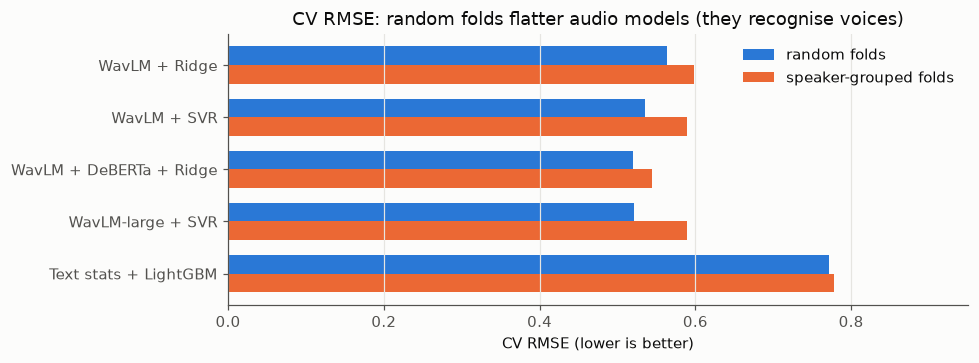

In [7]:
# How much each model's CV error grows once speakers can't leak (numbers from the experiment log).
cv_scheme = pd.DataFrame({
    "model": ["WavLM + Ridge", "WavLM + SVR", "WavLM + DeBERTa + Ridge", "WavLM-large + SVR", "Text stats + LightGBM"],
    "random folds": [0.564, 0.535, 0.520, 0.521, 0.771],
    "speaker-grouped folds": [0.598, 0.589, 0.544, 0.589, 0.778]})

fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.arange(len(cv_scheme)); h = 0.36
ax.barh(y - h / 2, cv_scheme["random folds"], h, color=BLUE, label="random folds")
ax.barh(y + h / 2, cv_scheme["speaker-grouped folds"], h, color=ORANGE, label="speaker-grouped folds")
ax.set_yticks(y, cv_scheme.model); ax.invert_yaxis()
ax.set(title="CV RMSE: random folds flatter audio models (they recognise voices)", xlabel="CV RMSE (lower is better)")
ax.set_xlim(0, 0.95)
ax.grid(axis="y", visible=False); ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

## 6. Evaluation on the training data

Two training-data RMSE figures, as required:
* **Out-of-fold (honest).** Every training clip is predicted by models that never saw its speaker, at test-like
  lengths (scored on its 4 crops). This is the number to judge the model by.
* **In-sample.** Every model refit on all training data and scored on that same data. It measures fit, not
  generalisation, so it's optimistic by construction.

In [8]:
blend08 = importlib.import_module("08_blend")
train03 = importlib.import_module("03_train")

oof = pd.read_parquet(ART / "oof_blend.parquet")             # written by 08_blend.py
rmse = lambda p, y: float(np.sqrt(np.mean((p - y) ** 2)))
pearson = lambda p, y: float(np.corrcoef(p, y)[0, 1])
print(f"Training RMSE (out-of-fold, speaker-grouped, test-length crops): {rmse(oof.oof, oof.label):.4f}")
print(f"Training Pearson (out-of-fold):                                  {pearson(oof.oof, oof.label):.4f}")
print(f"Training MAE (out-of-fold):                                      {np.abs(oof.oof - oof.label).mean():.4f}")

Training RMSE (out-of-fold, speaker-grouped, test-length crops): 0.5207
Training Pearson (out-of-fold):                                  0.9073
Training MAE (out-of-fold):                                      0.3897


In [9]:
# In-sample: refit every model on all training rows (full clips + crops), predict the full training clips,
# combine with the final blend weights, apply the score-0 gate.
key = ["filename", "split"]
ids = pd.read_parquet(ART / f"pred_{GATE[0]}.parquet").set_index(key)
is_tr = (ids.reset_index().split == "train").values
gated = (ids.pred < blend08.GATE).values[is_tr]
y_tr = ids.label.values[is_tr]

oof_preds = pd.concat([pd.read_parquet(ART / f"pred_{n}.parquet").set_index(key).pred.rename(n) for n, _, _ in MODELS],
                      axis=1).loc[ids.index].values[is_tr]
b0, w = blend08.fit(oof_preds[~gated], y_tr[~gated])          # the final blend weights (as in 08_blend.py)

fitted = []
for name, model, feats in MODELS:
    tr, _, crop, cols = train03.load_tables(feats, crops=True)
    rows = pd.concat([tr, crop], ignore_index=True)
    (p,) = train03.fit_predict(model, rows[cols], rows.label.values, [tr[cols]], seed=0)
    fitted.append(pd.Series(p, index=tr.filename).loc[ids.index.get_level_values(0)[is_tr]].values)
in_sample = np.where(gated, 0, np.clip(b0 + np.column_stack(fitted) @ w, 0, 5))
print(f"Training RMSE (in-sample):    {rmse(in_sample, y_tr):.4f}")
print(f"Training Pearson (in-sample): {pearson(in_sample, y_tr):.4f}")

Training RMSE (in-sample):    0.1194
Training Pearson (in-sample): 0.9961


The in-sample RMSE is far lower than the out-of-fold one because the RBF-kernel SVRs nearly memorise the clips
they were trained on. That gap is exactly why every model choice in this project was made on out-of-fold,
speaker-grouped numbers.

In [10]:
# Per-model results (speaker-grouped CV at test-length crops), from artifacts/results.csv.
res = pd.read_csv(ART / "results.csv").drop_duplicates("name", keep="last").set_index("name")
table = res.loc[[n for n, _, _ in MODELS], ["model", "feats", "cv_rmse", "cv_pearson"]]
table["blend weight"] = np.round(w, 3)
table.sort_values("cv_rmse")

,model,feats,cv_rmse,cv_pearson,blend weight
name,,,,,
c4c_svr_voxtral_wavlml,svr,feat_voxtral feat_wavlm-large,0.5794,0.8900,0.374
c4_ridge_whisper,ridge,feat_whisper-large-v3-turbo,0.5965,0.8770,0.110
c4_svr_wavlm-large,svr,feat_wavlm-large,0.5973,0.8782,0.334
t4_ridge_deberta,ridge,feat_emb_deberta-v3-large_prompt,0.7715,0.7824,0.316


## 7. Visual diagnostics

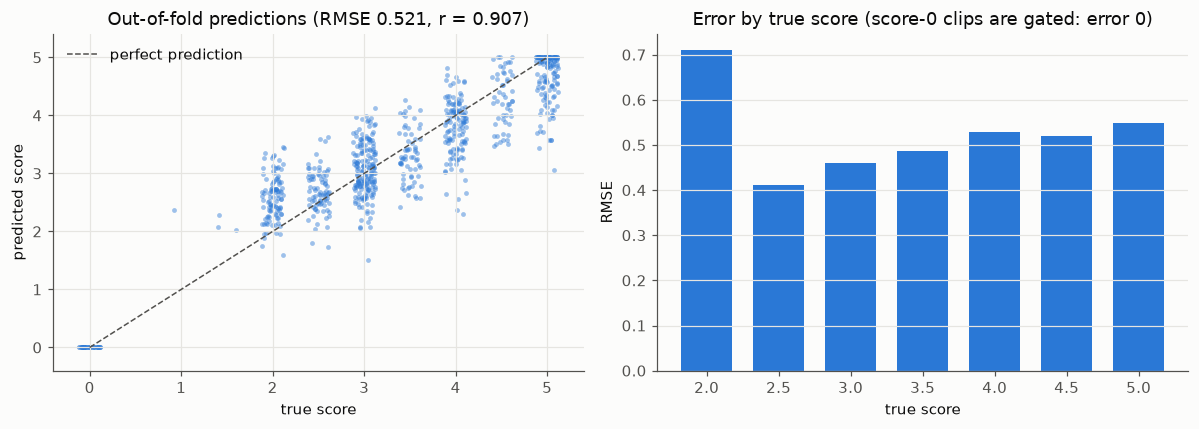

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Predicted vs actual (out-of-fold). Points jittered horizontally, labels are on a 0.5 grid.
jit = np.random.default_rng(0).uniform(-0.12, 0.12, len(oof))
axes[0].scatter(oof.label + jit, oof.oof, s=10, color=BLUE, alpha=0.45, linewidths=0)
axes[0].plot([0, 5], [0, 5], color=MUTED, lw=1, ls="--", label="perfect prediction")
axes[0].set(title=f"Out-of-fold predictions (RMSE {rmse(oof.oof, oof.label):.3f}, r = {pearson(oof.oof, oof.label):.3f})",
            xlabel="true score", ylabel="predicted score", xlim=(-0.4, 5.4), ylim=(-0.4, 5.4))
axes[0].legend(frameon=False, loc="upper left")

# Error by true score: predictions shrink toward the mean, so extremes carry most of the error.
# Score 0 is left out (the gate sets those clips to exactly 0), as are 1.0/1.5 (4 clips in total).
band = (((oof.oof - oof.label) ** 2).groupby(oof.label).mean() ** 0.5).drop(index=[0.0, 1.0, 1.5])
axes[1].bar(band.index.astype(str), band.values, color=BLUE, width=0.7)
axes[1].set(title="Error by true score (score-0 clips are gated: error 0)", xlabel="true score", ylabel="RMSE")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

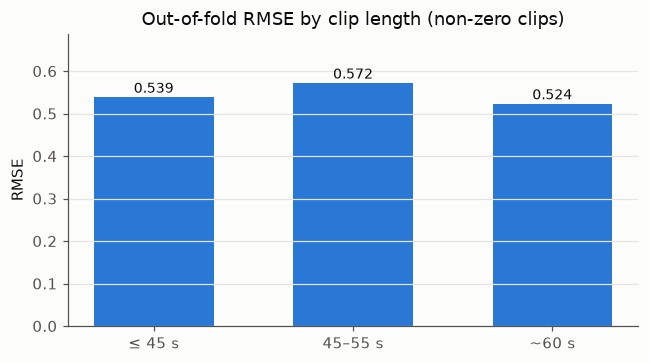

In [12]:
# Error by clip length, the shift that mattered most.
d = oof.merge(train[["filename", "duration"]], on="filename")
d = d[d.label > 0]
d["length"] = pd.cut(d.duration, [0, 45, 55, 62], labels=["≤ 45 s", "45–55 s", "~60 s"])
by_len = ((d.oof - d.label) ** 2).groupby(d.length, observed=True).mean() ** 0.5

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(by_len.index.astype(str), by_len.values, color=BLUE, width=0.6)
for i, v in enumerate(by_len.values):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", color=INK, fontsize=9)
ax.set(title="Out-of-fold RMSE by clip length (non-zero clips)", ylabel="RMSE", ylim=(0, by_len.max() * 1.2))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 8. Leaderboard progression and what we tested

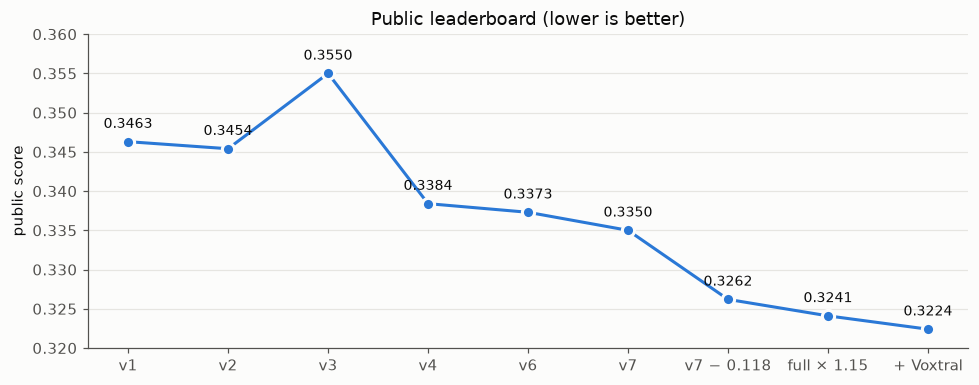

,version,change,public score
0,v1,"text + audio blend, score-0 gate",0.3463
1,v2,+ SVR on audio embeddings,0.3454
2,v3,"+ WavLM-large, Whisper encoder",0.3550
3,v4,SVRs trained on test-length crops,0.3384
4,v6,all models trained on 4 crops,0.3373
5,v7,+ text models on crop transcripts,0.3350
6,v7 − 0.118,remove measured test-set bias (§9),0.3262
7,full × 1.15,stretch full-length test clips (§9),0.3241
8,+ Voxtral,"audio language model features, 4-model blend",0.3224


In [13]:
lb = pd.DataFrame([
    ("v1", "text + audio blend, score-0 gate", 0.3463),
    ("v2", "+ SVR on audio embeddings", 0.3454),
    ("v3", "+ WavLM-large, Whisper encoder", 0.3550),
    ("v4", "SVRs trained on test-length crops", 0.3384),
    ("v6", "all models trained on 4 crops", 0.3373),
    ("v7", "+ text models on crop transcripts", 0.3350),
    ("v7 − 0.118", "remove measured test-set bias (§9)", 0.3262),
    ("full × 1.15", "stretch full-length test clips (§9)", 0.3241),
    ("+ Voxtral", "audio language model features, 4-model blend", 0.3224),
], columns=["version", "change", "public score"])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(lb.version, lb["public score"], color=BLUE, lw=2, marker="o", ms=8, markeredgecolor=SURFACE, markeredgewidth=2)
for x, v in zip(lb.version, lb["public score"]):
    ax.annotate(f"{v:.4f}", (x, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=INK)
ax.set(title="Public leaderboard (lower is better)", ylabel="public score", ylim=(0.32, 0.36))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
lb

**What we tested and learned**

| Idea | Outcome | Evidence |
|---|---|---|
| Verbatim Whisper prompt | Kept | Better text features than plain transcription (LightGBM CV RMSE 0.771 vs 0.792) |
| Audio embeddings (WavLM, Whisper encoder) | Kept | Strongest single view; SVR and Ridge on frozen embeddings |
| Score-0 gate | Kept | Catches all 37 score-0 training clips, no false positives |
| Speaker-grouped CV | Kept | Removes voice leakage; audio models lose most (table in §5) |
| Training on test-length crops (+ crop transcripts) | Kept | Biggest leaderboard gain: 0.3454 → 0.3350 |
| Rounding predictions to the 0.5 label grid | Dropped | Helps MAE but hurts RMSE; leaderboard +0.02 worse in two paired submissions |
| Post-hoc length correction (+0.14 on short clips) | Dropped | Leaderboard worse (0.3556); the blend wasn't under-predicting short clips |
| Grammar-error features (T5 corrector edit rate, CoLA acceptability, GPT-2 perplexity) | Dropped | Correlate with the score (r = 0.54) but add nothing beyond the embeddings |
| Fine-tuning DeBERTa / WavLM end-to-end | Dropped | Weaker than frozen embeddings + linear models on 769 clips; no blend gain |
| Removing the test-set bias (−0.118) | Kept | Measured with two shift probes, confirmed exactly (0.3350 → 0.3262); §9 |
| Length-specific bias correction | Not needed | The bias is about the same for short (+0.10) and full clips (+0.13) |
| Stretching full-length test predictions (× 1.15 around the mean) | Kept | Three probes, 0.3262 → 0.3241; §9 |
| Voxtral-Mini-3B hidden states (audio language model), with WavLM-large in one SVR | Kept | Best single model (CV RMSE 0.579); blend CV 0.5259 → 0.5207, leaderboard 0.3241 → 0.3224. Idea from another participant's public solution |
| Fewer models: one per kind of signal (text, Whisper encoder, WavLM-large, Voxtral) | Kept | 4 models beat 8 (CV RMSE 0.5207 vs 0.5280 for v7 + Voxtral) |
| LLM judge: Qwen3-8B scores each transcript against the rubric | Dropped | Correlates 0.62 with the score but nothing with the blend's errors (r = 0.005) |
| Voxtral asked for the score directly (1-5 probabilities) | Dropped | Zero-shot answers compressed (std 0.2), r = 0.45; no blend gain |
| Voxtral upper layers (60-90% of depth) | Dropped | Weaker than the lower-middle layers (CV RMSE 0.585 vs 0.579 with WavLM-large) |
| LanguageTool error rates by category | Dropped | Weak (r = -0.19 at best on transcripts of speech) |
| Offset for the 45.06 s recording batch | Dropped | Helps CV (0.528 → 0.523) but the leaderboard got worse (0.3320): the test batch differs |
| Stretching short test clips | Dropped | Leaderboard much worse (0.3248 → 0.3408); §9 |
| Test-time augmentation (20 s window grid shifted by 5, 10, 15 s) | Dropped | Every shifted view scored worse than the original grid |

**Limitations.** Only 769 training clips; the public leaderboard scores 216 test clips, so differences under
about 0.01 are mostly noise (CV and leaderboard disagreed on v3 and v8). Predictions are pulled toward the
mean (the regression-to-the-mean pattern in §7), so the extremes, scores 1.5–2 and 5, carry the largest errors.

## 9. The leaderboard metric and the test-set bias

The competition evaluates with **RMSE and Pearson correlation**. Adding a constant `c` to every prediction leaves
Pearson unchanged and changes RMSE in a known way, so two shifted copies of v7 test what the score is made of:

| Submission | Public score |
|---|---|
| v7 | 0.3350 |
| v7 + 0.2 | 0.3849 |
| v7 − 0.2 | 0.3305 |

* **Not pure RMSE.** For pure RMSE, LB(+)² + LB(−)² would equal 2·0.3350² + 2·0.2² = 0.3045. It is 0.2574, so part
  of the score doesn't move under a constant shift: the Pearson component. Better models improve both parts
  together, which is why the score kept falling as the blend improved.
* **A test-set bias.** Solving the same equations under every plausible combination of RMSE and Pearson gives the
  same answer: v7's test predictions are **0.118 too high on average**. The predicted score after removing it
  (0.3259–0.3264) matched the actual result, **0.3262**.
* **Where it comes from.** It's the same for short (+0.10) and full-length (+0.13) test clips (two more probes), and
  cross-validation on the training clips shows no bias (−0.008). So it isn't a modelling artifact: the test speakers
  simply score about 0.25 lower on average than the training speakers (implied mean 3.23 vs 3.48). A constant shift is
  the right correction for that.

**The spread.** v7's test predictions are also compressed: standard deviation 0.80, against 1.12 for its
out-of-fold predictions on the training clips. Stretching predictions around their mean, `mean + s·(pred − mean)`,
leaves Pearson unchanged, so three probes on top of v7 − 0.118 test where the compression is an error:

| Submission | Public score |
|---|---|
| v7 − 0.118 | 0.3262 |
| all clips × 1.15 | 0.3248 |
| all clips × 1.15, short clips (≤ 55 s) a further × 1.2 | 0.3408 |
| full-length clips (> 55 s) × 1.15, short clips unchanged | **0.3241** |

The gain is all in the full-length clips. The short clips' narrower spread (0.65, against 1.04 for full-length
clips) is real: those speakers sit closer to the middle of the scale, and stretching them costs score.

The final submission applies both corrections to the 4-model blend: the same test mean as v7 minus 0.118 (the
blend's test mean is 0.0074 above v7's, so the shift is −0.1254), then the full-length clips stretched by 1.15
around the mean of all predictions, clipped to [0, 5].

## 10. Submission

In [14]:
TEST_SHIFT = -0.1254  # measured test-set bias of v7 (-0.118), plus this blend's 0.0074 higher test mean (§9)
FULL_STRETCH = 1.15   # spread correction for full-length test clips (> 55 s), measured with probes (§9)
sub = pd.read_csv(ART / "submission.csv")   # the final blend from 08_blend.py
assert list(sub.columns) == ["filename", "label"] and len(sub) == len(test) and set(sub.filename) == set(test.filename)
sub["label"] = sub.label + TEST_SHIFT
full = sub.filename.map(test.set_index("filename").duration) > 55
mean = sub.label.mean()
sub.loc[full, "label"] = mean + FULL_STRETCH * (sub.label[full] - mean)
sub["label"] = sub.label.clip(0, 5)
assert sub.label.between(0, 5).all()
out = Path("/kaggle/working/submission.csv") if ON_KAGGLE else ART / "submission_final.csv"
sub.to_csv(out, index=False)
print(f"{len(sub)} predictions written to {out}; score range {sub.label.min():.2f}-{sub.label.max():.2f}")
sub.head()

216 predictions written to D:\SHLHIRINGASS\artifacts\submission_final.csv; score range 1.35-5.00


,filename,label
0,audio_128.wav,3.140078
1,audio_156.wav,3.758926
2,audio_19.wav,4.448025
3,audio_108.wav,1.757039
4,audio_206.wav,2.046856
